In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("titanic.csv")

In [5]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [6]:
print(df.tail())

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [7]:
print(df.shape)

(891, 12)


In [8]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [9]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [11]:
df = df.drop(columns=["Cabin"])

In [12]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [13]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [14]:
print(df.groupby("Sex")["Survived"].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [19]:
print(df.groupby("Pclass")["Survived"].mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [20]:
print(df["Age"].mean())

29.69911764705882


In [21]:
print(df["Fare"].mean())

32.204207968574636


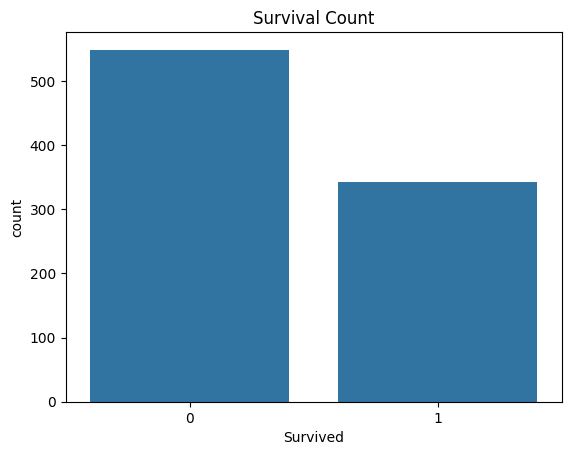

In [23]:
sns.countplot(x = "Survived", data=df)
plt.title("Survival Count")
plt.show()

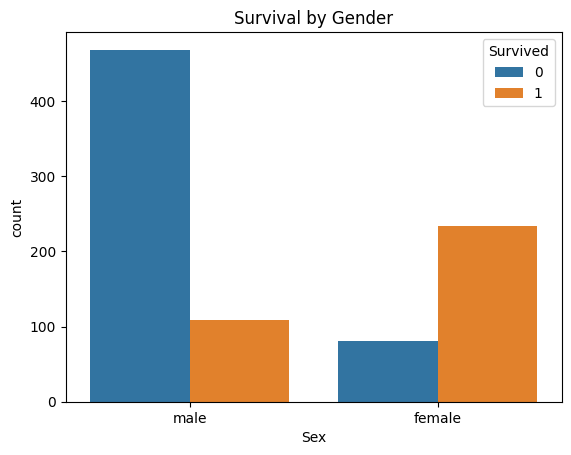

In [24]:
sns.countplot(x="Sex", hue = "Survived", data=df)
plt.title("Survival by Gender")
plt.show()

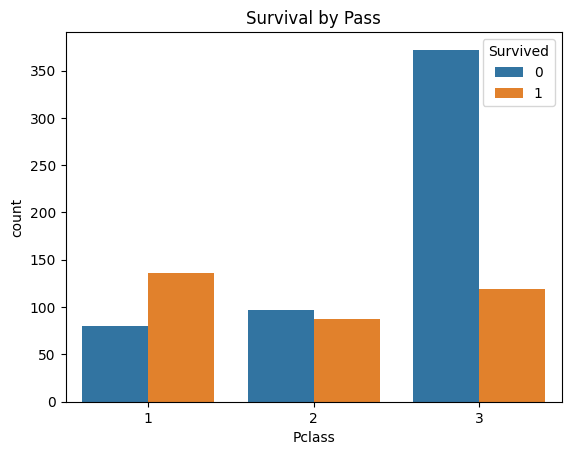

In [25]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Pass")
plt.show()

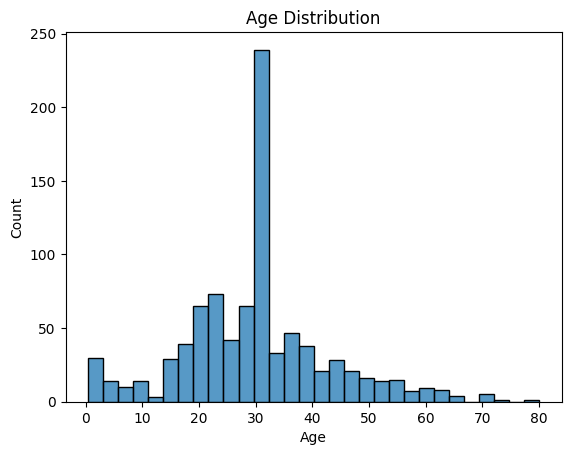

In [26]:
sns.histplot(df["Age"], bins=30)
plt.title("Age Distribution")
plt.show()

In [27]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 19, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

In [28]:
print(df.groupby("AgeGroup")["Survived"].mean())

AgeGroup
Child          0.579710
Teen           0.410526
Young Adult    0.352941
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


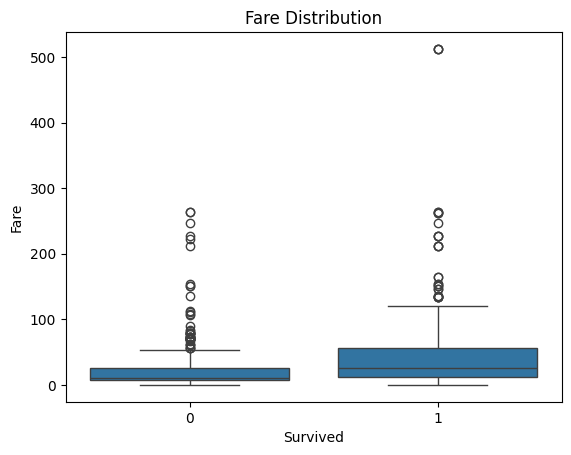

In [29]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Fare Distribution")
plt.show()

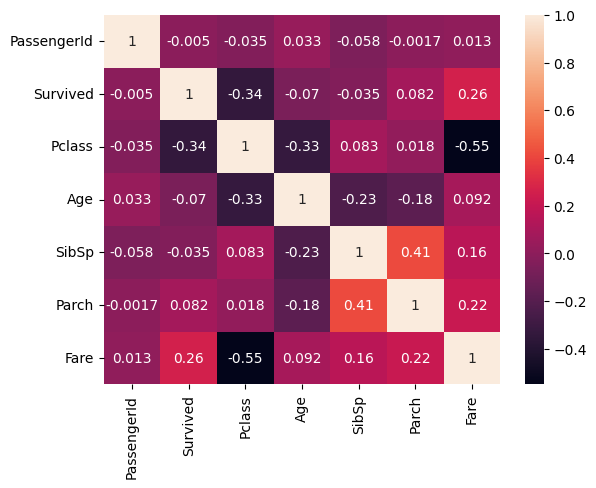

In [30]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

plt.show()